Dataset Loaded Successfully
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4       

C:\Users\hp\AppData\Local\Temp\ipykernel_25384\1134135084.py:67: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


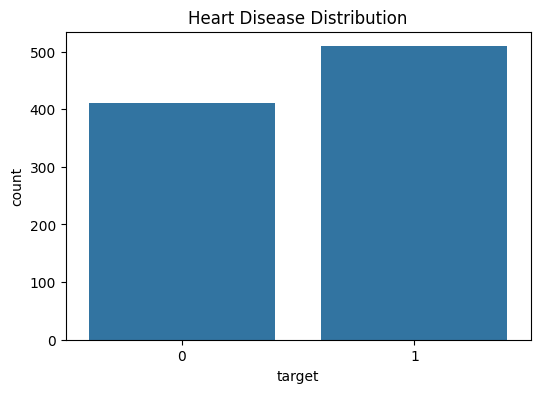

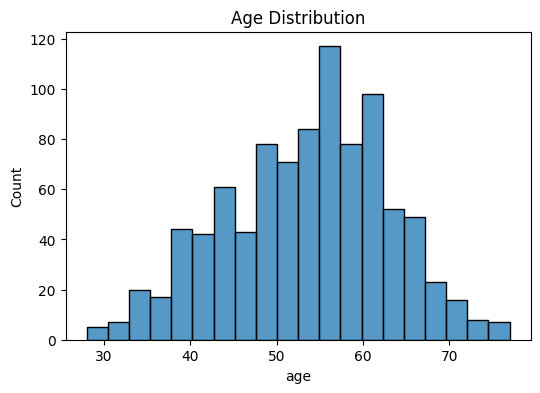

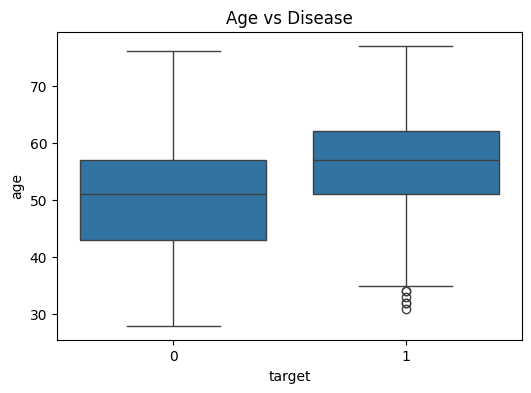

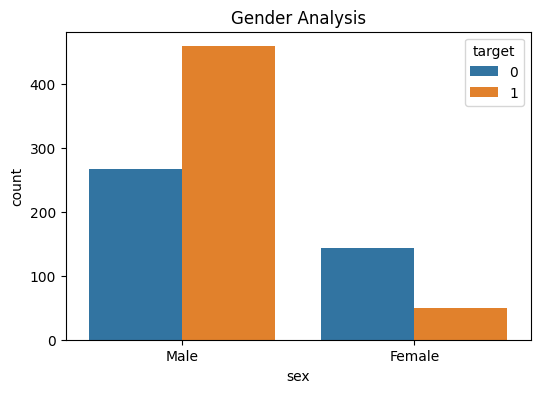

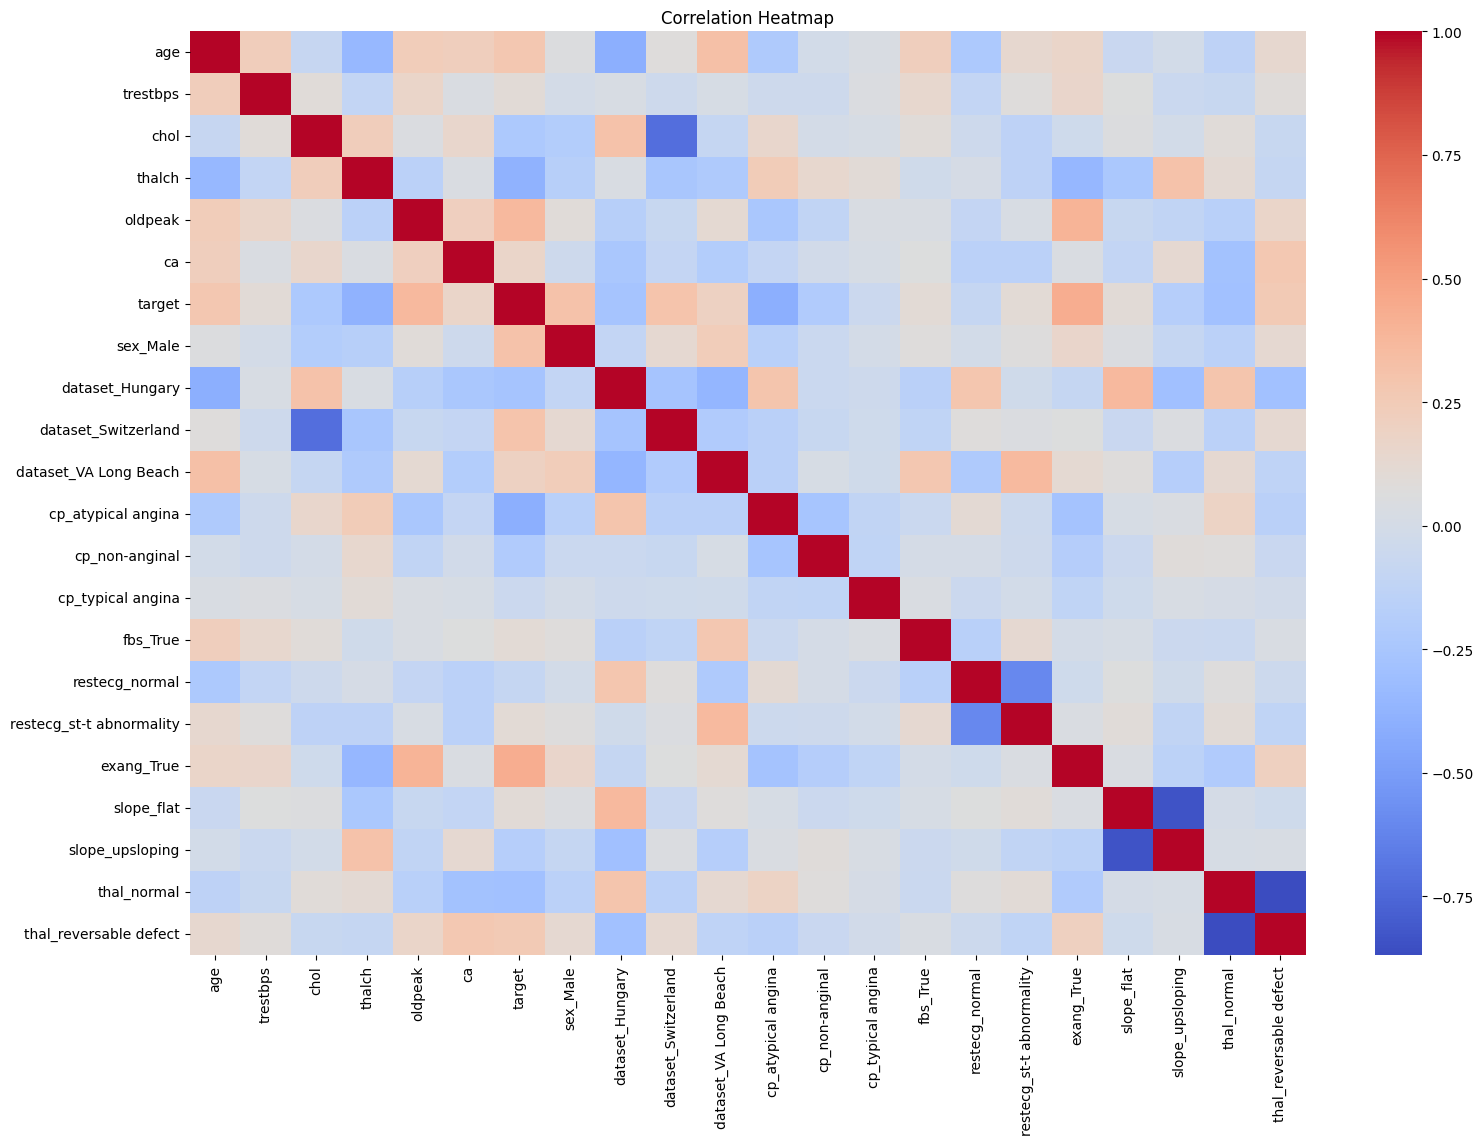


Accuracy
0.837

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix
[[63 19]
 [11 91]]


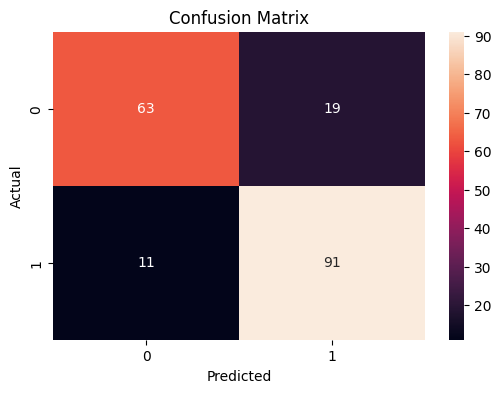


ROC AUC
0.921


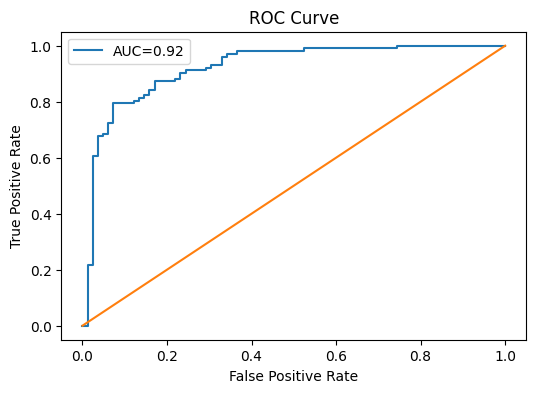


Top Important Features
                  Feature  Importance
8     dataset_Switzerland    1.293912
5                      ca    0.716865
4                 oldpeak    0.625548
9   dataset_VA Long Beach    0.545429
16             exang_True    0.515885
6                sex_Male    0.463632
17             slope_flat    0.438614
7         dataset_Hungary    0.240902
0                     age    0.228345
2                    chol    0.193239


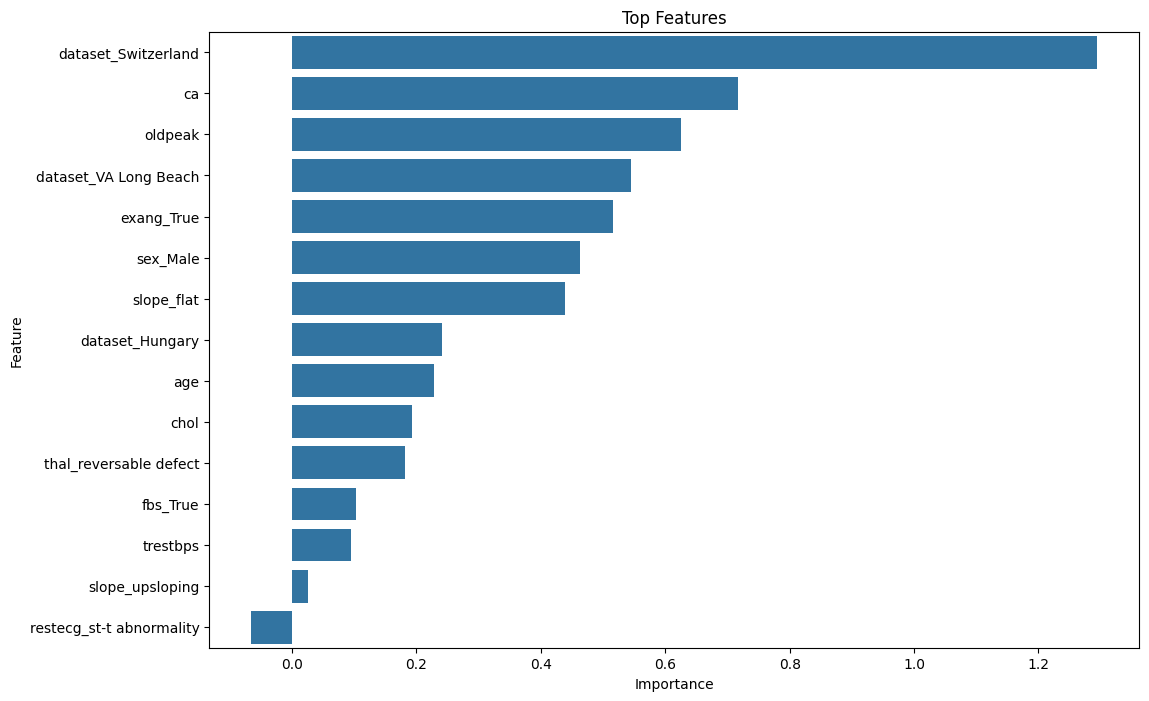


========== PROJECT SUMMARY ==========
Rows: 920
Columns: 22
Accuracy: 0.837
ROC AUC: 0.921


In [3]:
# ==================================
# HEART DISEASE PREDICTION PROJECT
# ==================================

# -------- 1. Import libraries --------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# -------- 2. Load dataset --------

df = pd.read_csv("heart_disease_uci.csv")

print("Dataset Loaded Successfully")

print(df.head())

print("\nShape:")

print(df.shape)

print("\nColumns:")

print(df.columns)


# -------- 3. Create Binary Target --------

# 0 = No disease
# 1,2,3,4 = Disease

df['target'] = (df['num'] > 0).astype(int)

# Remove original num column

df.drop(columns=['num'], inplace=True)


# -------- 4. Remove ID --------

df.drop(columns=['id'], inplace=True)


# -------- 5. Handle Missing Values --------

numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = df.select_dtypes(
    include=['object','bool']
).columns


# Fill numeric missing values

for col in numeric_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )


# Fill categorical missing values

for col in categorical_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )


print("\nMissing Values After Cleaning")

print(df.isnull().sum())


# -------- 6. EDA --------

# Target Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Heart Disease Distribution")

plt.show()


# Age Distribution

plt.figure(figsize=(6,4))

sns.histplot(
    df['age'],
    bins=20
)

plt.title("Age Distribution")

plt.show()


# Age vs Disease

plt.figure(figsize=(6,4))

sns.boxplot(
    x='target',
    y='age',
    data=df
)

plt.title("Age vs Disease")

plt.show()


# Gender Analysis

plt.figure(figsize=(6,4))

sns.countplot(
    x='sex',
    hue='target',
    data=df
)

plt.title("Gender Analysis")

plt.show()


# -------- 7. One Hot Encoding --------

df = pd.get_dummies(

    df,

    drop_first=True

)


# -------- 8. Correlation Heatmap --------

plt.figure(figsize=(18,12))

sns.heatmap(

    df.corr(),

    cmap='coolwarm'

)

plt.title("Correlation Heatmap")

plt.show()


# -------- 9. Features and Target --------

X = df.drop(

    'target',

    axis=1

)

y = df['target']


# -------- 10. Train Test Split --------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


# -------- 11. Feature Scaling --------

scaler = StandardScaler()

X_train = scaler.fit_transform(

    X_train

)

X_test = scaler.transform(

    X_test

)


# -------- 12. Train Logistic Regression --------

model = LogisticRegression(

    max_iter=5000

)

model.fit(

    X_train,

    y_train

)


# -------- 13. Predictions --------

y_pred = model.predict(

    X_test

)

y_prob = model.predict_proba(

    X_test

)[:,1]


# -------- 14. Accuracy --------

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("\nAccuracy")

print(round(accuracy,3))


# -------- 15. Classification Report --------

print("\nClassification Report")

print(

classification_report(

y_test,

y_pred

)

)


# -------- 16. Confusion Matrix --------

cm = confusion_matrix(

    y_test,

    y_pred

)

print("\nConfusion Matrix")

print(cm)


plt.figure(figsize=(6,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


# -------- 17. ROC Curve --------

auc = roc_auc_score(

    y_test,

    y_prob

)

print("\nROC AUC")

print(round(auc,3))


fpr,tpr,thresholds = roc_curve(

    y_test,

    y_prob

)


plt.figure(figsize=(6,4))

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.2f}"

)

plt.plot(

    [0,1],

    [0,1]

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


# -------- 18. Feature Importance --------

feature_names = X.columns

importance = pd.DataFrame({

'Feature':feature_names,

'Importance':model.coef_[0]

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

print("\nTop Important Features")

print(

importance.head(10)

)


plt.figure(figsize=(12,8))

sns.barplot(

    data=importance.head(15),

    x='Importance',

    y='Feature'

)

plt.title("Top Features")

plt.show()


# -------- 19. Final Summary --------

print("\n========== PROJECT SUMMARY ==========")

print("Rows:",df.shape[0])

print("Columns:",df.shape[1])

print("Accuracy:",round(accuracy,3))

print("ROC AUC:",round(auc,3))